###**Data Science Final Project Report**
###**Clustering Countries Using K-Means for HELP International**

In [ ]:
# Import the numpy and pandas libraries, then read the CSV file
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
df = pd.read_csv('Data_Negara_HELP.csv')
df

,Negara,Kematian_anak,Ekspor,Kesehatan,Impor,Pendapatan,Inflasi,Harapan_hidup,Jumlah_fertiliti,GDPperkapita
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [ ]:
# Check the data types and view the statistical descriptions of the data
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Negara            167 non-null    object 
 1   Kematian_anak     167 non-null    float64
 2   Ekspor            167 non-null    float64
 3   Kesehatan         167 non-null    float64
 4   Impor             167 non-null    float64
 5   Pendapatan        167 non-null    int64  
 6   Inflasi           167 non-null    float64
 7   Harapan_hidup     167 non-null    float64
 8   Jumlah_fertiliti  167 non-null    float64
 9   GDPperkapita      167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,Kematian_anak,Ekspor,Kesehatan,Impor,Pendapatan,Inflasi,Harapan_hidup,Jumlah_fertiliti,GDPperkapita
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Handling Missing Values

In [ ]:
# Checking for null or empty values
print(df.isnull().sum())

Negara              0
Kematian_anak       0
Ekspor              0
Kesehatan           0
Impor               0
Pendapatan          0
Inflasi             0
Harapan_hidup       0
Jumlah_fertiliti    0
GDPperkapita        0
dtype: int64


### Creating a Heatmap to Identify Correlations Between Data

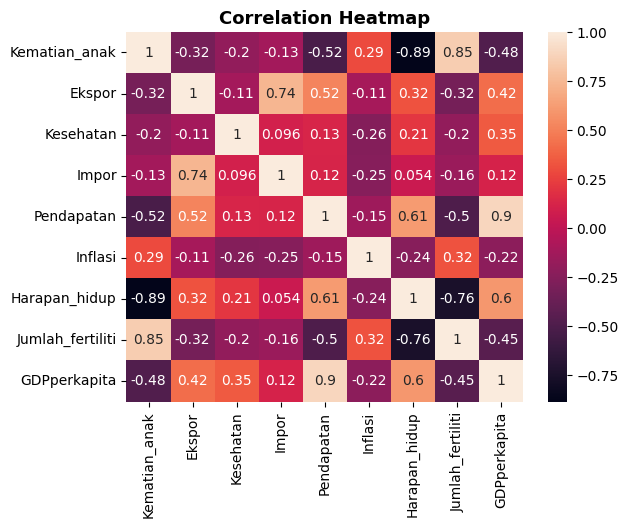

In [ ]:
# Creating Heatmap
numeric_df = df.select_dtypes(include=['number'])
plt.title('Correlation Heatmap',fontweight="bold", size=13)
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2g')
plt.show()

## Handling Outliers

In [ ]:
# Finding outliers using the “finding outliers” function
def finding_outlier_IQR(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    df_final = df[((df<(Q1-1.5*IQR))|(df > (Q3 + 1.5*IQR)))]
    return df_final


In [ ]:
print("\nPendapatan: ",finding_outlier_IQR(df['Pendapatan']))
print("\nKematian_anak: ",finding_outlier_IQR(df['Kematian_anak']))


Pendapatan:  23      80600
82      75200
91      91700
114     62300
123    125000
133     72100
145     55500
157     57600
Name: Pendapatan, dtype: int64

Kematian_anak:  31     149.0
32     150.0
66     208.0
132    160.0
Name: Kematian_anak, dtype: float64


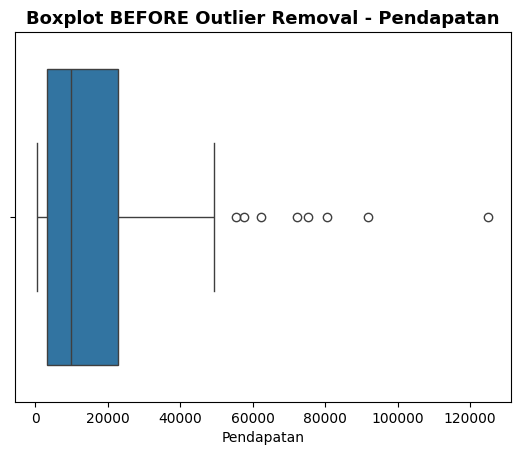

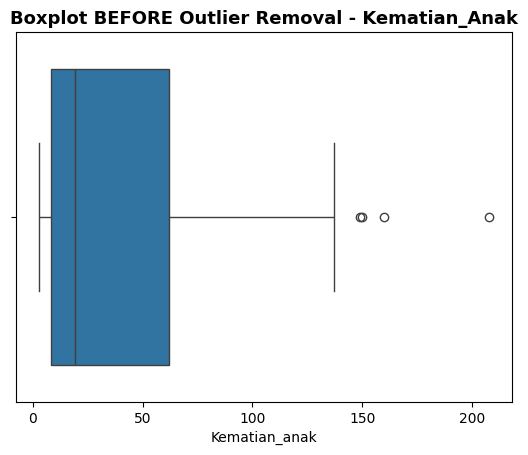

In [ ]:
plt.title('Boxplot BEFORE Outlier Removal - Pendapatan',fontweight="bold", size=13)
sns.boxplot(x='Pendapatan', data=df)
plt.show()
plt.title('Boxplot BEFORE Outlier Removal - Kematian_Anak',fontweight="bold", size=13)
sns.boxplot(x='Kematian_anak', data=df)
plt.show()

In [ ]:
# Handling Outliers with the Remove Outliers Function
def remove_outlier_IQR(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    df_final = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))]
    return df_final

In [ ]:
df_removed_outlier_clean = remove_outlier_IQR(df[['Pendapatan', 'Kematian_anak']])
df_removed_outlier = df_removed_outlier_clean.dropna(axis=0)

In [ ]:
clean_index = df_removed_outlier.index
df_clean_all_cols = df.loc[clean_index].copy()
df_removed_outlier = df_removed_outlier.reset_index(drop=True)
df_clean_all_cols

,Negara,Kematian_anak,Ekspor,Kesehatan,Impor,Pendapatan,Inflasi,Harapan_hidup,Jumlah_fertiliti,GDPperkapita
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


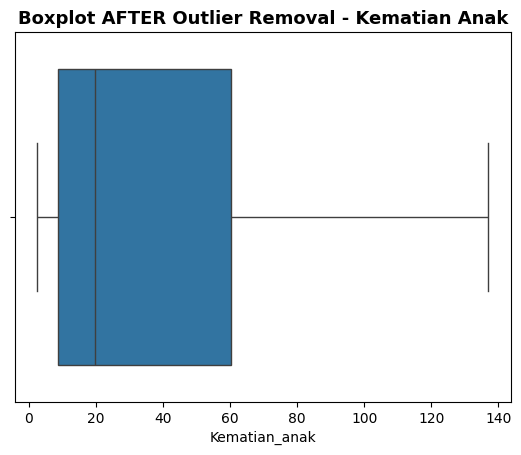

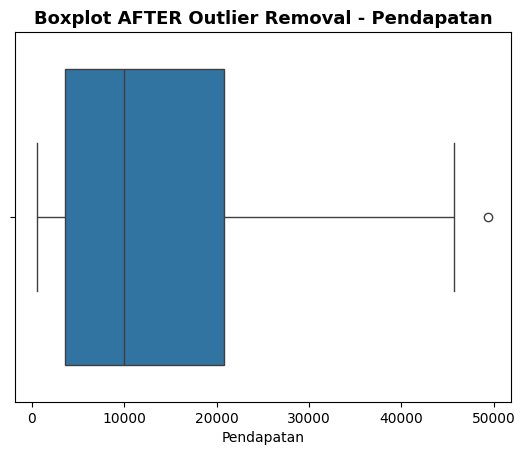

In [ ]:
plt.title('Boxplot AFTER Outlier Removal - Kematian Anak',fontweight="bold", size=13)
sns.boxplot(x='Kematian_anak', data=df_removed_outlier)
plt.show()
plt.title('Boxplot AFTER Outlier Removal - Pendapatan',fontweight="bold", size=13)
sns.boxplot(x='Pendapatan', data=df_removed_outlier)
plt.show()

## Univariate Analysis

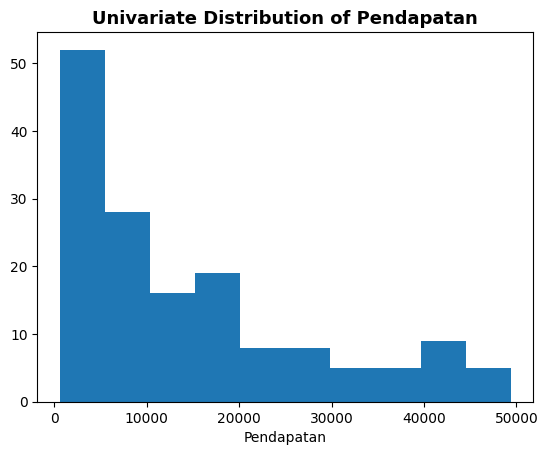

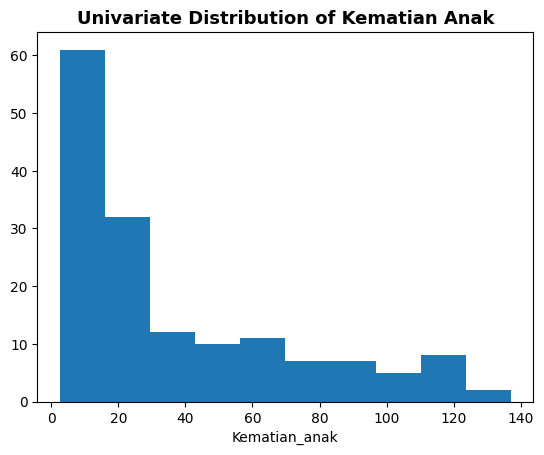

In [ ]:
fig, ax= plt.subplots()
plt.title('Univariate Distribution of Pendapatan',fontweight="bold", size=13)
ax.hist(df_removed_outlier['Pendapatan'])
ax.set_xlabel('Pendapatan')
plt.show()

fig, ax= plt.subplots()
plt.title('Univariate Distribution of Kematian Anak',fontweight="bold", size=13)
ax.hist(df_removed_outlier['Kematian_anak'])
ax.set_xlabel('Kematian_anak')
plt.show()

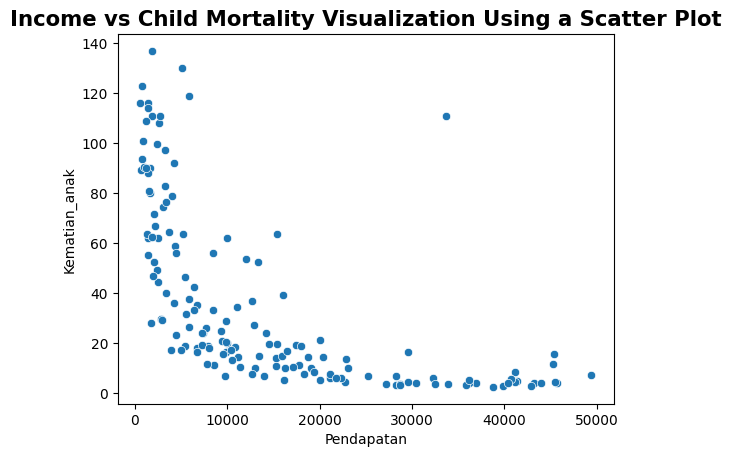

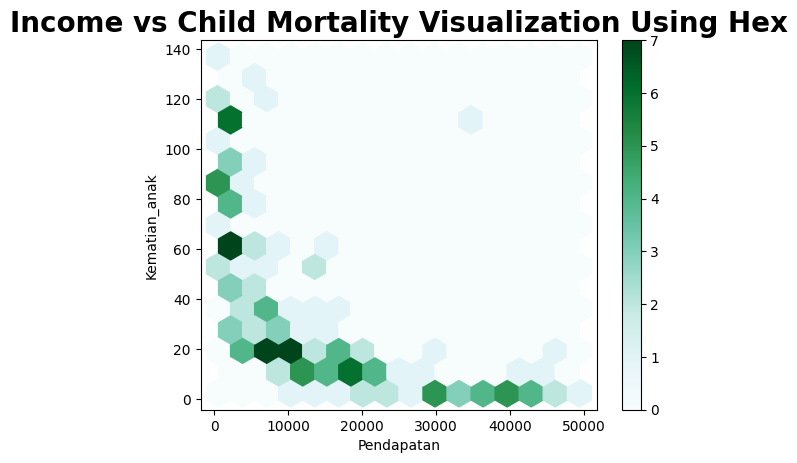

In [ ]:
# Income vs. Child Mortality
sns.scatterplot(x='Pendapatan',y='Kematian_anak', data=df_removed_outlier)
plt.title('Income vs Child Mortality Visualization Using a Scatter Plot',fontweight="bold", size=15.359)

df_removed_outlier.plot.hexbin(x='Pendapatan', y='Kematian_anak', gridsize=15)
plt.title('Income vs Child Mortality Visualization Using Hex',fontweight="bold", size=20)
plt.show()

## Data Clustering

In [ ]:
# Scaling Data
sc = StandardScaler()
dfoutlier_std = sc.fit_transform(df_removed_outlier.astype(float))
dfoutlier_std

array([[-0.97531632,  1.51906422],
       [-0.34266015, -0.56653887],
       [-0.11682014, -0.26333298],
       [-0.64910298,  2.33516977],
       [ 0.35463038, -0.74506196],
       [ 0.32421421, -0.62604656],
       [-0.58827066, -0.52403337],
       [ 2.05033143, -0.90091545],
       [ 2.18720416, -0.91508395],
       [ 0.11890512,  0.0738773 ],
       [ 0.64358392, -0.64588246],
       [ 2.02751931, -0.79323486],
       [-0.91220279,  0.36291468],
       [ 0.06567683, -0.63454766],
       [ 0.1341132 , -0.88107955],
       [ 2.02751931, -0.90941655],
       [-0.49854298, -0.50419747],
       [-0.95934784,  2.10847379],
       [-0.60956197,  0.17305679],
       [-0.68636278,  0.28357109],
       [-0.35862863, -0.84140775],
       [-0.08640398,  0.45075938],
       [ 0.00484451, -0.47586047],
       [ 0.06567683, -0.73089346],
       [-0.9890036 ,  2.25015878],
       [-1.03964651,  1.61541001],
       [-0.90611955,  0.22122969],
       [-0.8954739 ,  2.02346279],
       [ 1.99710315,

In [ ]:
# Clustering using KMeans k = 2
kmeans1 = KMeans(n_clusters = 2, random_state = 42, n_init= 10).fit(dfoutlier_std)
labels1 = kmeans1.labels_
new_dfoutlier_std = pd.DataFrame(data =dfoutlier_std, columns= ['Pendapatan', 'Kematian_anak'])
new_dfoutlier_std['label_kmeans1'] = labels1

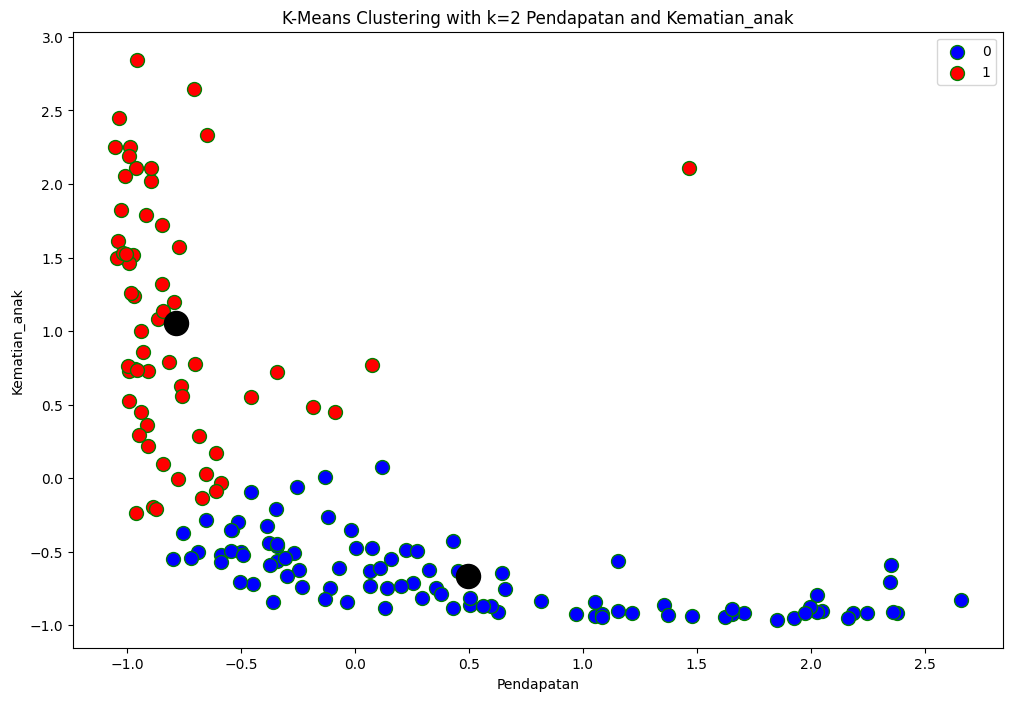

In [ ]:
# Cluster Visualization (k=2)
plt.figure(figsize=(12,8))
plt.scatter(new_dfoutlier_std.Pendapatan[new_dfoutlier_std.label_kmeans1 == 0], new_dfoutlier_std['Kematian_anak'][new_dfoutlier_std.label_kmeans1 == 0], c='blue', edgecolor='green', s=100, ls='-', label= 0)
plt.scatter(new_dfoutlier_std.Pendapatan[new_dfoutlier_std.label_kmeans1 == 1], new_dfoutlier_std['Kematian_anak'][new_dfoutlier_std.label_kmeans1 == 1], c='red', edgecolor='green', s=100, ls='-', label = 1)

centers = kmeans1.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=300)
plt.xlabel('Pendapatan')
plt.ylabel('Kematian_anak')
plt.legend()
plt.title('K-Means Clustering with k=2 Pendapatan and Kematian_anak')
plt.show()

[309.99999999999994, 140.00033623897517, 59.98596841448345, 40.32440226213868, 28.68815597367921, 23.173367044159033, 18.284107483750223, 14.1384634661949, 11.983619184500094, 9.929389661745384]


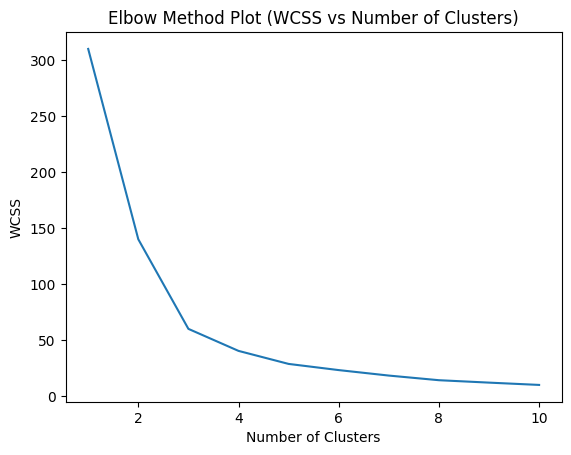

In [ ]:
# Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state = 42, n_init=10)
    kmeans.fit(dfoutlier_std)
    wcss.append(kmeans.inertia_)
print(wcss)
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method Plot (WCSS vs Number of Clusters)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# Clustering using KMeans k = 3
kmeans2 = KMeans(n_clusters = 3, random_state = 42, n_init= 10).fit(dfoutlier_std)
labels2 = kmeans2.labels_
new_dfoutlier_std = pd.DataFrame(data =dfoutlier_std, columns= ['Pendapatan', 'Kematian_anak'])
new_dfoutlier_std['label_kmeans2'] = labels2

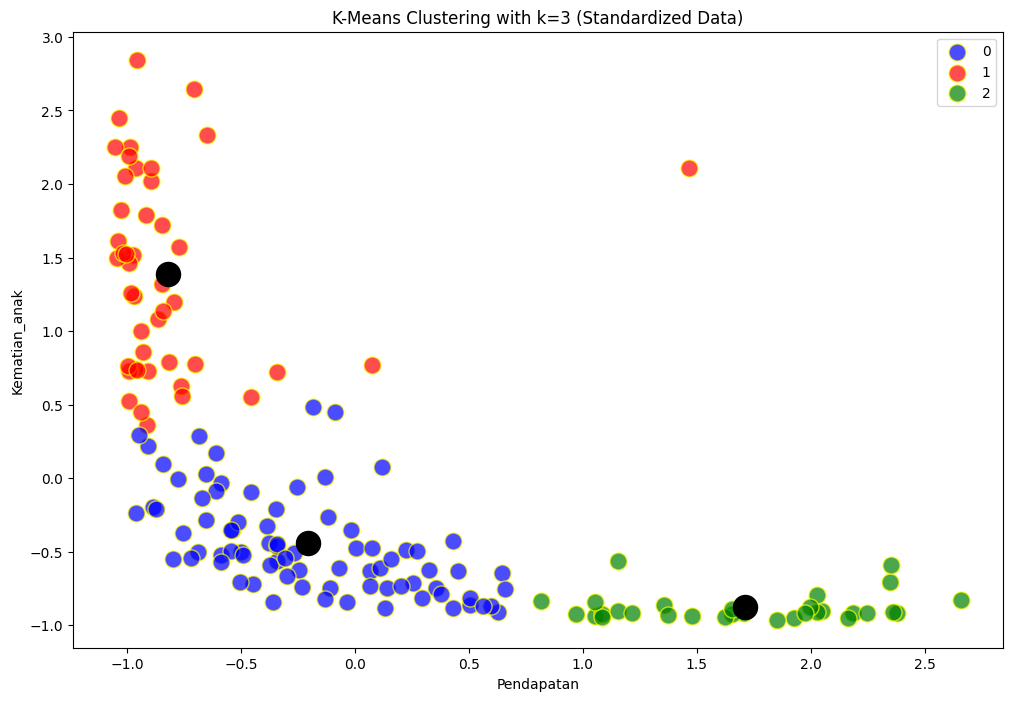

In [ ]:
# Cluster Visualization (k=3)
color_map = {
    0: 'blue',
    1: 'red',
    2: 'green'
}

plt.figure(figsize=(12,8))

for label in [1, 0, 2]:
    plt.scatter(
        new_dfoutlier_std.loc[new_dfoutlier_std.label_kmeans2 == label, 'Pendapatan'],
        new_dfoutlier_std.loc[new_dfoutlier_std.label_kmeans2 == label, 'Kematian_anak'],
        c=color_map[label],
        edgecolor='yellow',
        s=150,
        alpha=0.7,
        label=label
    )

plt.xlabel('Pendapatan')
plt.ylabel('Kematian_anak')
plt.title('K-Means Clustering with k=3 (Standardized Data)')
centers2 = kmeans2.cluster_centers_
plt.scatter(centers2[:, 0], centers2[:, 1], centers2[:, 2], c='black', s=300)
handles, labels = plt.gca().get_legend_handles_labels()


sorted_pairs = sorted(zip(labels, handles), key=lambda x: int(x[0]))

labels_sorted, handles_sorted = zip(*sorted_pairs)

plt.legend(handles_sorted, labels_sorted)
plt.show()

In [ ]:
print('k = 2: ',silhouette_score(dfoutlier_std, labels =labels1))
print('k = 3: ',silhouette_score(dfoutlier_std, labels =labels2))

k = 2:  0.4860716545496431
k = 3:  0.5569354023241216


## Clustering Using Original Values

In [ ]:
# Clustering using KMeans k = 3 ( Original Values )
kmeans3 = KMeans(n_clusters = 3, init = 'k-means++', random_state=42, n_init=10).fit(dfoutlier_std)
labels3 = kmeans3.labels_

In [ ]:
newdf = pd.DataFrame(data = sc.inverse_transform(dfoutlier_std), columns= ['Pendapatan', 'Kematian_anak'])
newdf['label_kmeans3'] = labels3

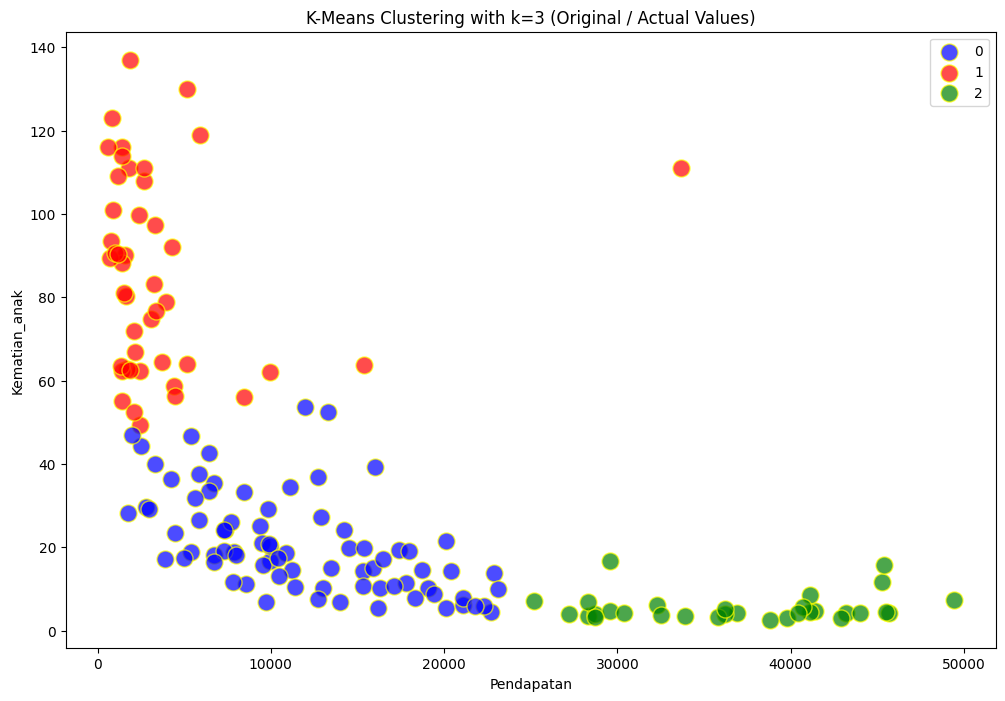

In [ ]:
color_map = {
    0: 'blue',
    1: 'red',
    2: 'green'
}

plt.figure(figsize=(12,8))

for label in [1, 0, 2]:
    plt.scatter(
        newdf.loc[newdf.label_kmeans3 == label, 'Pendapatan'],
        newdf.loc[newdf.label_kmeans3 == label, 'Kematian_anak'],
        c=color_map[label],
        edgecolor='yellow',
        s=150,
        alpha=0.7,
        label=label
    )

plt.xlabel('Pendapatan')
plt.ylabel('Kematian_anak')
plt.title('K-Means Clustering with k=3 (Original / Actual Values)')
handles, labels = plt.gca().get_legend_handles_labels()


sorted_pairs = sorted(zip(labels, handles), key=lambda x: int(x[0]))

labels_sorted, handles_sorted = zip(*sorted_pairs)

plt.legend(handles_sorted, labels_sorted)
plt.show()

In [ ]:
# Displaying Data with Label_kmeans
df_clean_all_cols['label'] = pd.Series(labels3).astype('object')
df_clean_all_cols

,Negara,Kematian_anak,Ekspor,Kesehatan,Impor,Pendapatan,Inflasi,Harapan_hidup,Jumlah_fertiliti,GDPperkapita,label
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0
...,...,...,...,...,...,...,...,...,...,...,...
150,Togo,90.3,40.2,7.65,57.3,1210,1.18,58.7,4.87,488,0
151,Tonga,17.4,12.4,5.07,60.3,4980,3.68,69.9,3.91,3550,0
152,Tunisia,17.4,50.5,6.21,55.3,10400,3.82,76.9,2.14,4140,0
153,Turkey,19.1,20.4,6.74,25.5,18000,7.01,78.2,2.15,10700,1


In [ ]:
df_clean_all_cols['Kematian_anak'].mean()

np.float64(38.84774193548387)

In [ ]:
df_clean_all_cols['Pendapatan'].mean()

np.float64(17145.567741935483)

## Rekomendasi

In [ ]:
# Finding the Countries with the Lowest Child Mortality Rates and Income Levels
cari_negara = df_clean_all_cols[df_clean_all_cols['label']==1]

In [ ]:
# Finding the 5 Countries with the Lowest Income
cari_negara.sort_values(by=['Pendapatan'],ascending=True)[:5]

,Negara,Kematian_anak,Ekspor,Kesehatan,Impor,Pendapatan,Inflasi,Harapan_hidup,Jumlah_fertiliti,GDPperkapita,label
37,"Congo, Dem. Rep.",116.0,41.1,7.91,49.6,609,20.80,57.5,6.54,334,1
88,Liberia,89.3,19.1,11.80,92.6,700,5.47,60.8,5.02,327,1
106,Mozambique,101.0,31.5,5.21,46.2,918,7.64,54.5,5.56,419,1
132,Sierra Leone,160.0,16.8,13.10,34.5,1220,17.20,55.0,5.20,399,1
93,Madagascar,62.2,25.0,3.77,43.0,1390,8.79,60.8,4.60,413,1


In [ ]:
# Finding the 5 Countries with the Lowest Child Mortality Rates
cari_negara.sort_values(by=['Kematian_anak'],ascending=False)[:5]

,Negara,Kematian_anak,Ekspor,Kesehatan,Impor,Pendapatan,Inflasi,Harapan_hidup,Jumlah_fertiliti,GDPperkapita,label
132,Sierra Leone,160.0,16.8,13.10,34.5,1220,17.200,55.0,5.20,399,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,1
37,"Congo, Dem. Rep.",116.0,41.1,7.91,49.6,609,20.800,57.5,6.54,334,1
25,Burkina Faso,116.0,19.2,6.74,29.6,1430,6.810,57.9,5.87,575,1
17,Benin,111.0,23.8,4.10,37.2,1820,0.885,61.8,5.36,758,1


In [ ]:
# Country Scoring for Humanitarian Aid Priorities
# Normalization of Income and Child Mortality on a Scale of 0–1
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cari_negara_combined = df_clean_all_cols[df_clean_all_cols['label'] == 1].copy()

cari_negara_combined[['Pendapatan_norm', 'Kematian_norm']] = scaler.fit_transform(
    cari_negara_combined[['Pendapatan', 'Kematian_anak']]
)

# Composite score: low income + high child mortality
# Income is inverted (1 - standard deviation) so that low income corresponds to a high score
cari_negara_combined['skor'] = (1 - cari_negara_combined['Pendapatan_norm']) + cari_negara_combined['Kematian_norm']

# Show the top 8
top8 = cari_negara_combined.sort_values('skor', ascending=False)[['Negara', 'Pendapatan', 'Kematian_anak', 'skor']].head(8)
top8.index = range(1, 9)  # 1–8
top8

,Negara,Pendapatan,Kematian_anak,skor
1,Sierra Leone,1220,160.0,1.993292
2,"Congo, Dem. Rep.",609,116.0,1.720102
3,Burkina Faso,1430,116.0,1.711089
4,Angola,5900,119.0,1.681101
5,Benin,1820,111.0,1.675001
6,Mozambique,918,101.0,1.621290
7,Lesotho,2380,99.7,1.596970
8,Liberia,700,89.3,1.549255
